In [1]:
"""
Combined z-score PKR DMS heatmap.

Takes a LONG-format input `df` (columns: pkr, k3, site, wt_aa, var_aa, auc_mean),
runs zscore_df() to collapse the selected K3 conditions into a single
'combined z-scores' value per PKR variant, then draws ONE heatmap of that
combined score with contact / annotation tracks for:

    eIF2a, vaccinia, variola, tanapox, ranavirus, positive selection, conserved.

External variables expected in scope:
    df        -> long-format DataFrame described above
    save_dir  -> output directory for the SVG
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import zscore
from matplotlib.transforms import offset_copy

In [6]:
# input file
input_file = '../../results/barseq/combined_grouped-barcodes_241120.csv'
df = pd.read_csv(input_file)

# figure save directory
save_dir = "../../img/heatmaps"
os.makedirs(save_dir, exist_ok=True)

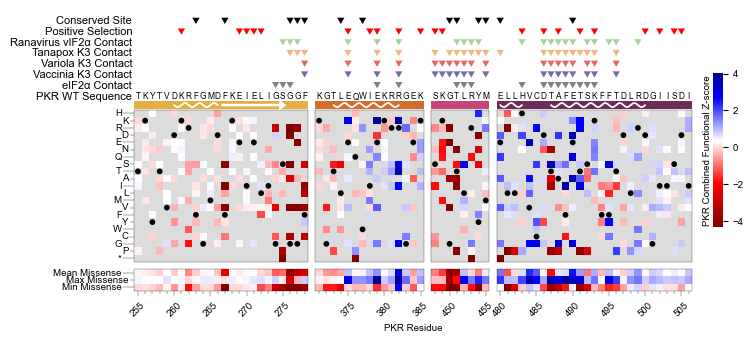

# ChimeraX Coloring: Combined Z-score, Scoring Condition: Mean Missense
color #1/A #6dc091 cartoon;color #1/A:255 #fff5f5 cartoon;color #1/A:256 #ffeded cartoon;color #1/A:257 #ffe5e5 cartoon;color #1/A:258 #ffd1d1 cartoon;color #1/A:259 #fdfdff cartoon;color #1/A:260 #ffcdcd cartoon;color #1/A:261 #fffdfd cartoon;color #1/A:262 #ff8989 cartoon;color #1/A:263 #ffcdcd cartoon;color #1/A:264 #fff5f5 cartoon;color #1/A:265 #fff9f9 cartoon;color #1/A:266 #ffc9c9 cartoon;color #1/A:267 #ec0000 cartoon;color #1/A:268 #fffdfd cartoon;color #1/A:269 #ffe9e9 cartoon;color #1/A:270 #fff9f9 cartoon;color #1/A:271 #fdfdff cartoon;color #1/A:272 #ffd9d9 cartoon;color #1/A:273 #ffc9c9 cartoon;color #1/A:274 #ff5d5d cartoon;color #1/A:275 #ff6969 cartoon;color #1/A:276 #980000 cartoon;color #1/A:277 #c00000 cartoon;color #1/A:278 #da0000 cartoon;color #1/A:371 #ffd9d9 cartoon;color #1/A:372 #ff9999 cartoon;color #1/A:373 #ff8d8d cartoon;color #1/A:374 #ffa5a5 cartoon;color #1/A:375 #c1c1ff cartoon;co

In [7]:
# plot parameters
plt.rcParams['font.family'] = 'Arial'


# ----------------------------------------------------------------------------
# z-scoring
# ----------------------------------------------------------------------------
def zscore_df(df, cond_list):
    """Generates a combined z-score for the specified list of K3 conditions"""

    temp_df = df.pivot_table(
        index=['pkr'],
        columns='k3',
        values='auc_mean',
        dropna=False
    )

    temp_df.reset_index(inplace=True)
    temp_df.index.name = None
    site_map = dict(zip(df['pkr'], df['site']))
    wt_map = dict(zip(df['pkr'], df['wt_aa']))
    var_map = dict(zip(df['pkr'], df['var_aa']))
    temp_df['site'] = temp_df['pkr'].map(site_map)
    temp_df['wt_aa'] = temp_df['pkr'].map(wt_map)
    temp_df['var_aa'] = temp_df['pkr'].map(var_map)

    z_cols = []
    for cond in cond_list:
        z_col = f"{cond} z-score"
        z_cols.append(z_col)
        # NOTE: with dropna=False above, condition columns can contain NaNs.
        # scipy.stats.zscore PROPAGATES NaN by default, which would turn the
        # whole column (and therefore the combined score) into NaN. Using
        # nan_policy='omit' computes mean/std over the non-NaN values instead.
        temp_df[z_col] = zscore(temp_df[cond], nan_policy='omit')

    k = len(z_cols)
    # row[z_cols].sum() skips NaN, so a variant missing in one condition still
    # gets a combined score from its remaining conditions (denominator stays sqrt(k)).
    temp_df['combined z-scores'] = temp_df.apply(lambda row: row[z_cols].sum() / np.sqrt(k), axis=1)
    return temp_df


def custom_cmap(cmap_name, center, vmin, vmax):
    """Pulled from seaborn matrix.py to center cmap on WT value"""
    cmap = mpl.colormaps[cmap_name]
    under = cmap(-np.inf)
    over = cmap(np.inf)
    under_set = under != cmap(0)
    over_set = over != cmap(cmap.N - 1)

    vrange = max(vmax - center, center - vmin)
    normlize = mpl.colors.Normalize(center - vrange, center + vrange)
    cmin, cmax = normlize([vmin, vmax])
    cc = np.linspace(cmin, cmax, 256)
    cmap = mpl.colors.ListedColormap(cmap(cc))
    cmap.set_bad(color='gainsboro')
    if under_set:
        cmap.set_under(under)
    if over_set:
        cmap.set_over(over)

    return cmap


def parse_pdb_secondary_structure(pdb_path, chain_id):
    """
    Parse HELIX and SHEET records from a PDB file for a specific chain.

    PDB HELIX record (fixed columns, 1-indexed per PDB spec):
        cols 20       -> initial chain ID
        cols 22-25    -> initial residue seqnum (integer)
        cols 32       -> terminal chain ID
        cols 34-37    -> terminal residue seqnum (integer)

    PDB SHEET record:
        cols 22       -> initial chain ID
        cols 23-26    -> initial residue seqnum
        cols 33       -> terminal chain ID
        cols 34-37    -> terminal residue seqnum

    Returns a tuple (helices, strands) where each is a list of (start, end)
    inclusive integer residue ranges on the requested chain.
    """
    helices = []
    strands = []
    with open(pdb_path, 'r') as fh:
        for line in fh:
            rec = line[0:6]
            if rec == 'HELIX ':
                init_chain = line[19:20].strip()
                term_chain = line[31:32].strip()
                if init_chain == chain_id == term_chain:
                    try:
                        start = int(line[21:25].strip())
                        end = int(line[33:37].strip())
                        helices.append((start, end))
                    except ValueError:
                        continue
            elif rec == 'SHEET ':
                init_chain = line[21:22].strip()
                term_chain = line[32:33].strip()
                if init_chain == chain_id == term_chain:
                    try:
                        start = int(line[22:26].strip())
                        end = int(line[33:37].strip())
                        strands.append((start, end))
                    except ValueError:
                        continue
    return helices, strands


# new Roth-inspired AA order 250916MC
aa_list = ['H', 'K', 'R', 'D', 'E', 'N', 'Q', 'S', 'T', 'A', 'I', 'L', 'M', 'V', 'F', 'Y', 'W', 'C', 'G', 'P', '*']

aa_no_stops = aa_list.copy()
aa_no_stops.remove("*")

# Define the 4 PKR structural regions (inclusive ranges)
pkr_sections = [(255, 278), (371, 385), (448, 455), (480, 506)]

# Sentinel column labels for the white gaps between sections
GAP_COLS = ['__gap1__', '__gap2__', '__gap3__']
# Sentinel row label for the white gap above the summary rows
GAP_ROW = '__row_gap__'

# ----------------------------------------------------------------------------
# CHANGED: this is now a SINGLE combined-z-score heatmap, not one-per-K3.
#
# ZSCORE_COND_LIST -> which K3 conditions are combined into the z-score by
# zscore_df(). This is a modeling choice and is independent of which contact
# tracks are drawn below. Default excludes the K3Δ58 control (a non-functional
# pseudosubstrate would skew the per-condition distributions). Edit as needed.
# ----------------------------------------------------------------------------
ZSCORE_COND_LIST = ['VACV K3', 'VARV C3', 'TPV K3', 'RCVZ vIF2α']

VALUE_COL = 'combined z-scores'                    # column produced by zscore_df to plot
CBAR_LABEL = 'PKR Combined Functional Z-score'     # colorbar label
CONDITION_LABEL = 'Combined Z-score'               # used in filename + ChimeraX export header

# ----------------------------------------------------------------------------
# TOGGLE 1: show WT sequence letters above the heatmap
# ----------------------------------------------------------------------------
SHOW_WT_SEQUENCE = True
WT_SEQ_LABEL = 'PKR WT Sequence'
WT_SEQ_LABEL_FONT_SIZE = 8
WT_SEQ_FONT_SIZE = 6
WT_SEQ_FONT_FAMILY = 'Arial'

# ----------------------------------------------------------------------------
# TOGGLE 2: contact / annotation triangle tracks shown above the heatmap.
# ----------------------------------------------------------------------------
SHOW_CONTACT_TRACKS = True

CONTACT_TRACK_DICT = {
  "eIF2a": {
      "label": "eIF2α Contact",
      "color": "gray",
      "sites": [274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
    },
  "vacv": {
    "label": "Vaccinia K3 Contact",
    "color": "#786BAC",
    "sites": [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "varv": {
    "label": "Variola K3 Contact",
    "color": "#E86562",
    "sites": [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "tpv": {
    "label": "Tanapox K3 Contact",
    "color": "#F4B681",
    "sites": [276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
    },
  "myxv": {
    "label": "Myxoma K3 Contact",
    "color": "#6BB3FC",
    "sites": [275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
    },
  "rcv": {
    "label": "Ranavirus vIF2α Contact",
    "color": "#A8D39B",
    "sites": [275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]
    },
  "conserved": {
    "label": "Conserved Site",
    "color": "black",
    "sites": [263, 267, 276, 277, 278, 279, 281, 283, 296, 298, 308, 309, 312, 315, 317, 319, 320, 323, 327, 362, 364, 365, 366, 367, 369, 374, 377, 397, 401, 404, 406, 407, 410, 411, 412, 413, 414, 415, 416, 417, 419, 420, 429, 430, 431, 432, 433, 437, 444, 445, 446, 450, 451, 454, 455, 457, 458, 459, 465, 469, 470, 474, 475, 476, 477, 480, 490, 511, 519, 523, 526]
    },
  "positive_vert": {
    "label": "Positive Selection",
    "color": "red",
    "sites": [261, 269, 270, 271, 272, 307, 314, 322, 360, 368, 375, 378, 379, 382, 385, 389, 394, 405, 428, 448, 449, 462, 471, 483, 486, 488, 491, 493, 500, 502, 504, 505, 514, 520, 524]
    }
}

# ----------------------------------------------------------------------------
# CHANGED: single fixed track set for the combined heatmap (was a per-K3 dict).
# Order is TOP-to-BOTTOM: the first key is the topmost track (farthest from the
# heatmap); the last key sits closest to the heatmap. This ordering keeps the
# original convention (conserved/positive at top, the K3 contacts grouped, and
# eIF2α nearest the map). Reorder freely to change vertical stacking.
# ----------------------------------------------------------------------------
COMBINED_TRACK_KEYS = ["conserved","positive_vert","rcv","tpv","varv","vacv","eIF2a"]

CONTACT_LABEL_FONT_SIZE = 8
CONTACT_TRACK_HEIGHT = 1.0
CONTACT_TRACK_SPACING_PT = 3.2

# ----------------------------------------------------------------------------
# TOGGLE 3: secondary-structure track derived from a PDB file.
# ----------------------------------------------------------------------------
SHOW_SECONDARY_STRUCTURE = True
PDB_PATH = '../../data/2A1A.pdb'
PDB_CHAIN = 'B'
SS_TRACK_HEIGHT = 1.2
SS_GAP_TO_WT = 0.1
SS_GAP_TO_HEATMAP = 0.05
SS_SECTION_COLORS = ['#E2B040', '#D46D2B', '#C3467E', '#6E2A59']
SS_GLYPH_COLOR = 'white'
SS_HELIX_AMPLITUDE = 0.28
SS_HELIX_PERIOD = 2.0
SS_HELIX_LINEWIDTH = 1.3
SS_STRAND_THICKNESS = 0.35
SS_STRAND_HEAD_LENGTH = 1.0
SS_STRAND_HEAD_WIDTH = 0.75


# ============================================================================
# CHANGED: run z-scoring on the long-format input df, then plot ONE heatmap.
# (The former `for k3, k3_name in zip(...)` loop is gone; the body below runs once.)
# ============================================================================
z_df = zscore_df(df, ZSCORE_COND_LIST)

width_in = 8
height_in = 4
stroke = .25
font = 'Arial'
font_size = 7
cmap_color = 'seismic_r'

# custom cmap centered on PKR-WT's COMBINED z-score (white = WT-like function)
z_center = z_df.query('pkr == "PKR-WT"').iloc[0][VALUE_COL]
z_min = z_df[VALUE_COL].min()
z_max = z_df[VALUE_COL].max()
centered_cmap = custom_cmap(cmap_color, z_center, z_min, z_max)

# Build the full site list across all 4 sections with gap sentinels inserted between them
ordered_cols = []
for i, (lo, hi) in enumerate(pkr_sections):
    ordered_cols.extend(list(range(lo, hi + 1)))
    if i < len(pkr_sections) - 1:
        ordered_cols.append(GAP_COLS[i])

# Filter data to the union of all region sites
all_region_sites = [c for c in ordered_cols if isinstance(c, int)]
temp_df = z_df[z_df['site'].isin(all_region_sites)].copy()
temp_df['site'] = temp_df['site'].astype(int)

# remove wt
region_df = temp_df.query('pkr != "PKR-WT"')

# --- WT black-circle dataframe ---
cols = ['site', 'wt_aa']
wt_df = region_df[cols].drop_duplicates()
wt_df['site'] = wt_df['site'].astype(int)
wt_df = wt_df.sort_values('site').set_index('site')
wt_df = pd.get_dummies(wt_df['wt_aa'])
missing_wt = list(set(aa_list) - set(wt_df.columns.tolist()))
for aa in missing_wt:
    wt_df[aa] = False
wt_df = wt_df[aa_list]
wt_df.replace({True: 1, False: np.nan}, inplace=True)
wt_df['Mean Missense'] = np.nan
wt_df['Max Missense'] = np.nan
wt_df['Min Missense'] = np.nan
wt_df = wt_df.T  # rows = AAs + summary labels, cols = sites

# Insert gap columns (all NaN) between sections
for g in GAP_COLS:
    wt_df[g] = np.nan

# Reorder columns to match section layout
wt_df = wt_df[ordered_cols]

# Insert the white spacer ROW above the three summary rows
summary_rows = ['Mean Missense', 'Max Missense', 'Min Missense']
main_rows = [r for r in wt_df.index if r not in summary_rows]
wt_df.loc[GAP_ROW] = np.nan
wt_df = wt_df.loc[main_rows + [GAP_ROW] + summary_rows]
wt_array = wt_df.values

# --- Main data dataframe (CHANGED: pivot on the combined z-score, not auc_mean) ---
region_df = region_df.pivot(index='site', columns='var_aa', values=VALUE_COL)
region_df = region_df.reindex(columns=aa_list)   # tolerate any AA absent from the data
region_df['Mean Missense'] = region_df[aa_no_stops].mean(axis=1)
region_df['Max Missense'] = region_df[aa_no_stops].max(axis=1)
region_df['Min Missense'] = region_df[aa_no_stops].min(axis=1)
region_df = region_df.T  # rows = AAs + summary, cols = sites

# Insert gap columns
for g in GAP_COLS:
    region_df[g] = np.nan

# Reorder columns
region_df = region_df[ordered_cols]

# Insert gap row above summary rows
region_df.loc[GAP_ROW] = np.nan
region_df = region_df.loc[main_rows + [GAP_ROW] + summary_rows]

# --- Plot ---
font = {'family': font, 'size': font_size}
plt.figure(figsize=(width_in, height_in))

min_value = region_df.min().min()
max_value = region_df.max().max()
# CHANGED: combined z-scores can span a wider range than AUC; coarsen the
# colorbar ticks when the range is large so they don't collide.
z_span = max_value - min_value
tick_step = 1 if z_span <= 8 else 2
even_ticks = np.arange(np.ceil(min_value), np.floor(max_value) + 1, tick_step)

cbar_kws = {
    'aspect': 15,
    'orientation': 'vertical',
    'fraction': .05,
    'pad': .05,
    'shrink': .5,
    'anchor': (-.5, .5),
    'ticks': even_ticks,
}

g = sns.heatmap(
    data=region_df,
    cmap=centered_cmap,
    vmin=z_min,
    vmax=z_max,
    square=True,
    cbar_kws=cbar_kws,
)

# --- Overlay WHITE rectangles on the gap columns & gap row ---
col_labels = list(region_df.columns)
row_labels = list(region_df.index)

gap_col_idx = [i for i, c in enumerate(col_labels) if c in GAP_COLS]
gap_row_idx = [i for i, r in enumerate(row_labels) if r == GAP_ROW]

n_rows = len(row_labels)
n_cols = len(col_labels)

for ci in gap_col_idx:
    g.add_patch(plt.Rectangle((ci, 0), 1, n_rows, facecolor='white',
                              edgecolor='none', zorder=3, clip_on=False))
for ri in gap_row_idx:
    g.add_patch(plt.Rectangle((0, ri), n_cols, 1, facecolor='white',
                              edgecolor='none', zorder=3, clip_on=False))

# --- WT black circles ---
for i in range(len(wt_array)):
    for j in range(len(wt_array[i])):
        if np.isnan(wt_array[i, j]):
            continue
        if wt_array[i, j] == 1:
            circle = plt.Circle((j + 0.5, i + 0.5), 0.3, color='black', fill=True, zorder=4)
            g.add_artist(circle)

# --- Colorbar (CHANGED: label reflects the combined z-score) ---
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=font_size)
cbar.set_label(CBAR_LABEL, rotation=90, labelpad=1, font=font, size=font_size)
cbar.ax.yaxis.set_label_position('left')

# --- Labels / ticks ---
plt.xticks(fontproperties=font, fontsize=font_size)
plt.yticks(fontproperties=font, fontsize=font_size)

g.set_ylabel('')
g.set_xlabel('PKR Residue', font=font, size=font_size)

y_display_labels = ['' if r == GAP_ROW else r for r in row_labels]
g.set_yticks(np.arange(len(row_labels)) + 0.5)
g.set_yticklabels(y_display_labels, rotation=0, fontproperties=font)

plt.tick_params(axis='both', which='both', width=stroke)

fig = plt.gcf()
ax = plt.gca()

summary_offsets = {
    'Mean Missense': -2,
    'Max Missense': 3,
    'Min Missense': -2,
}

major_ticks = ax.yaxis.get_major_ticks()
aa_counter = 0
for i, tick in enumerate(major_ticks):
    row_label = row_labels[i]
    if row_label == GAP_ROW:
        tick.tick1line.set_markersize(0)
        continue
    tick_length = 8 if i % 2 == 0 else 3
    tick.tick1line.set_markersize(tick_length)

    dx_points = None
    if row_label in aa_list:
        dx_points = -2 if aa_counter % 2 == 0 else 3
        aa_counter += 1
    elif row_label in summary_offsets:
        dx_points = summary_offsets[row_label]

    if dx_points is not None:
        label = tick.label1
        label.set_transform(
            offset_copy(label.get_transform(), fig=fig, x=dx_points, y=0, units='points')
        )

# X tick labels: major ticks every 5 residues, skipping gap columns
x_index = []
x_value = []
for i, x in enumerate(col_labels):
    if isinstance(x, int) and x % 5 == 0:
        x_index.append(i + 0.5)
        x_value.append(x)
g.set_xticks(x_index)
g.set_xticklabels(x_value, fontproperties=font, rotation=45)

minor_positions = [i + 0.5 for i, c in enumerate(col_labels) if isinstance(c, int)]
g.set_xticks(minor_positions, minor=True)

# --- Section outlines ---
for spine in g.spines.values():
    spine.set_visible(False)

section_spans = []
current_start = None
current_end = None
for i, c in enumerate(col_labels):
    if isinstance(c, int):
        if current_start is None:
            current_start = i
        current_end = i
    else:
        if current_start is not None:
            section_spans.append((current_start, current_end))
            current_start = None
if current_start is not None:
    section_spans.append((current_start, current_end))

gap_row_position = next(i for i, r in enumerate(row_labels) if r == GAP_ROW)
row_blocks = [
    (0, gap_row_position - 1),
    (gap_row_position + 1, len(row_labels) - 1),
]

section_stroke = 0.2
for (c_start, c_end) in section_spans:
    for (r_start, r_end) in row_blocks:
        rect = plt.Rectangle(
            (c_start, r_start),
            (c_end - c_start + 1),
            (r_end - r_start + 1),
            fill=False,
            edgecolor='black',
            linewidth=section_stroke,
            zorder=5,
            clip_on=False,
        )
        g.add_patch(rect)

# ------------------------------------------------------------------
# Helpers for anything drawn ABOVE the heatmap
# ------------------------------------------------------------------
site_to_colidx = {c: i for i, c in enumerate(col_labels) if isinstance(c, int)}
# CHANGED: WT AA lookup now comes from the z-scored df.
site_to_wt = (
    z_df[['site', 'wt_aa']]
    .drop_duplicates()
    .dropna()
    .assign(site=lambda d: d['site'].astype(int))
    .set_index('site')['wt_aa']
    .to_dict()
)


def _points_to_data_y(pts):
    trans = ax.transData
    inv = trans.inverted()
    dpi = fig.get_dpi()
    px = pts * dpi / 72.0
    d0 = trans.transform((0, 0))
    d1 = (d0[0], d0[1] + px)
    y0 = inv.transform(d0)[1]
    y1 = inv.transform(d1)[1]
    return abs(y1 - y0)


content_top_y = 0.0

# ------------------------------------------------------------------
# TOGGLE 3: secondary-structure track (closest to heatmap)
# ------------------------------------------------------------------
if SHOW_SECONDARY_STRUCTURE:
    helices, strands = parse_pdb_secondary_structure(PDB_PATH, PDB_CHAIN)

    content_top_y -= SS_GAP_TO_HEATMAP

    ss_top_y = content_top_y - SS_TRACK_HEIGHT
    ss_mid_y = (content_top_y + ss_top_y) / 2.0

    for (lo, hi), color, (c_start, c_end) in zip(
        pkr_sections, SS_SECTION_COLORS, section_spans
    ):
        rect = plt.Rectangle(
            (c_start, ss_top_y),
            (c_end - c_start + 1),
            SS_TRACK_HEIGHT,
            facecolor=color,
            edgecolor='none',
            zorder=5,
            clip_on=False,
        )
        g.add_patch(rect)

    def _clip_to_sections(start, end):
        for (lo, hi), (c_start, c_end) in zip(pkr_sections, section_spans):
            if end < lo or start > hi:
                continue
            r0 = max(start, lo)
            r1 = min(end, hi)
            yield c_start, c_end, r0, r1

    for (h_start, h_end) in helices:
        for c_start, c_end, r0, r1 in _clip_to_sections(h_start, h_end):
            section_idx = next(i for i, (lo, hi) in enumerate(pkr_sections) if lo <= r0 <= hi)
            section_lo = pkr_sections[section_idx][0]
            x0 = c_start + (r0 - section_lo) + 0.5
            x1 = c_start + (r1 - section_lo) + 0.5
            if x1 <= x0:
                continue
            n_samples = max(int((x1 - x0) * 25), 10)
            xs = np.linspace(x0, x1, n_samples)
            ys = ss_mid_y + SS_HELIX_AMPLITUDE * np.sin(
                2 * np.pi * (xs - x0) / SS_HELIX_PERIOD
            )
            g.plot(
                xs, ys,
                color=SS_GLYPH_COLOR,
                linewidth=SS_HELIX_LINEWIDTH,
                solid_capstyle='round',
                zorder=6,
                clip_on=False,
            )

    for (s_start, s_end) in strands:
        for c_start, c_end, r0, r1 in _clip_to_sections(s_start, s_end):
            section_idx = next(i for i, (lo, hi) in enumerate(pkr_sections) if lo <= r0 <= hi)
            section_lo = pkr_sections[section_idx][0]
            x0 = c_start + (r0 - section_lo)
            x1 = c_start + (r1 - section_lo) + 1.0
            if x1 <= x0:
                continue

            shaft_half = SS_STRAND_THICKNESS / 2.0
            head_len = min(SS_STRAND_HEAD_LENGTH, (x1 - x0) * 0.6)
            head_half_width = SS_STRAND_HEAD_WIDTH

            arrow_pts = [
                (x0,                ss_mid_y - shaft_half),
                (x1 - head_len,     ss_mid_y - shaft_half),
                (x1 - head_len,     ss_mid_y - head_half_width),
                (x1,                ss_mid_y),
                (x1 - head_len,     ss_mid_y + head_half_width),
                (x1 - head_len,     ss_mid_y + shaft_half),
                (x0,                ss_mid_y + shaft_half),
            ]
            arrow = plt.Polygon(
                arrow_pts,
                closed=True,
                facecolor=SS_GLYPH_COLOR,
                edgecolor='none',
                zorder=6,
                clip_on=False,
            )
            g.add_patch(arrow)

    content_top_y = ss_top_y

# ------------------------------------------------------------------
# TOGGLE 1: WT sequence letters above the SS track (or heatmap)
# ------------------------------------------------------------------
if SHOW_WT_SEQUENCE:
    if SHOW_SECONDARY_STRUCTURE:
        content_top_y -= SS_GAP_TO_WT

    wt_row_height = 1.0
    wt_row_top = content_top_y - wt_row_height
    wt_row_center_y = wt_row_top + wt_row_height / 2.0

    for site, col_idx in site_to_colidx.items():
        wt_aa = site_to_wt.get(site)
        if wt_aa is None:
            continue
        g.text(
            col_idx + 0.5,
            wt_row_center_y,
            str(wt_aa),
            ha='center',
            va='center',
            fontsize=WT_SEQ_FONT_SIZE,
            family=WT_SEQ_FONT_FAMILY,
            color='black',
            clip_on=False,
            zorder=6,
        )

    if WT_SEQ_LABEL:
        g.text(
            -0.3,
            wt_row_center_y,
            WT_SEQ_LABEL,
            ha='right',
            va='center',
            fontsize=WT_SEQ_LABEL_FONT_SIZE,
            family='Arial',
            color='black',
            clip_on=False,
            zorder=6,
        )

    content_top_y = wt_row_top

# ------------------------------------------------------------------
# TOGGLE 2: contact / annotation triangle tracks (topmost)
# CHANGED: fixed 7-track set for the combined heatmap.
# ------------------------------------------------------------------
CONTACT_TRACKS = [CONTACT_TRACK_DICT[a] for a in COMBINED_TRACK_KEYS]

if SHOW_CONTACT_TRACKS and len(CONTACT_TRACKS) > 0:
    tri_height = (3 ** 0.5) / 2.0

    contact_track_spacing = _points_to_data_y(CONTACT_TRACK_SPACING_PT)

    content_top_y -= contact_track_spacing

    for track in reversed(CONTACT_TRACKS):
        label = track.get('label', '')
        sites = track.get('sites', [])
        color = track.get('color', '#000000')

        tip_y = content_top_y
        base_y = content_top_y - tri_height

        for site in sites:
            col_idx = site_to_colidx.get(int(site))
            if col_idx is None:
                continue
            x_center = col_idx + 0.5
            triangle = plt.Polygon(
                [
                    (x_center, tip_y),
                    (x_center - 0.5, base_y),
                    (x_center + 0.5, base_y),
                ],
                closed=True,
                facecolor=color,
                edgecolor='none',
                linewidth=0,
                zorder=6,
                clip_on=False,
            )
            g.add_patch(triangle)

        label_y = (tip_y + base_y) / 2.0
        g.text(
            -0.3,
            label_y,
            label,
            ha='right',
            va='center',
            fontsize=CONTACT_LABEL_FONT_SIZE,
            family='Arial',
            color='black',
            clip_on=False,
            zorder=6,
        )

        content_top_y = base_y - contact_track_spacing

# Extend the y-axis upward so annotations above the heatmap aren't clipped.
if content_top_y < 0:
    current_ylim = g.get_ylim()
    g.set_ylim(current_ylim[0], min(current_ylim[1], content_top_y - 0.5))

# save plot (CHANGED: single combined-condition filename)
plot_name = f'new-heatmap_{CONDITION_LABEL.replace(" ", "-")}_260708.svg'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()


# --- STRUCTURE COLORING (CHANGED: uses combined z-score range + z_df) ---
def color_structure(score_category='Mean Missense', depiction='surface'):
    numeric_cols = [c for c in region_df.columns if isinstance(c, int)]
    values = region_df.loc[score_category, numeric_cols].values
    values = values[~np.isnan(values)]
    norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
    colors = [centered_cmap(norm(value)) for value in values.flatten()]
    hex_colors = [mcolors.rgb2hex(color) for color in colors]
    pkr_sites = sorted(list(set(z_df.query('pkr != "PKR-WT"')['site'].astype(int).tolist())))

    cmd_list = []
    for site, color in zip(pkr_sites, hex_colors):
        cmd_list.append(f"color #1/A:{site} {color} {depiction};")

    print(f'# ChimeraX Coloring: {CONDITION_LABEL}, Scoring Condition: {score_category}')
    print(''.join([f'color #1/A #6dc091 {depiction};'] + cmd_list))
    print()


color_structure('Mean Missense', 'cartoon')
color_structure('Min Missense', 'cartoon')
color_structure('Max Missense', 'cartoon')
color_structure('Mean Missense', 'surface')
color_structure('Min Missense', 'surface')
color_structure('Max Missense', 'surface')

NameError: name 'save_dir' is not defined

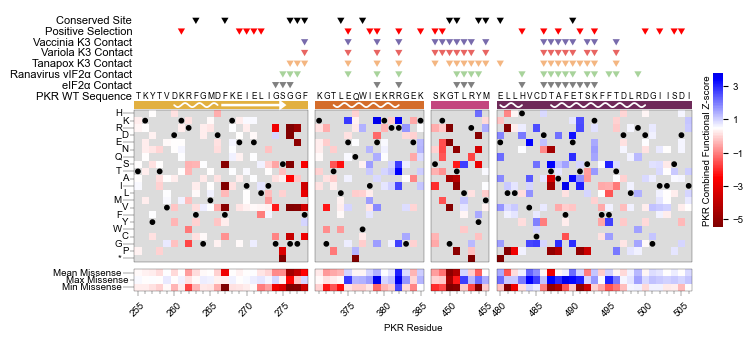

In [5]:
"""
Combined z-score PKR DMS heatmap.

Takes a LONG-format input `df` (columns: pkr, k3, site, wt_aa, var_aa, auc_mean),
runs zscore_df() to collapse the selected K3 conditions into a single
'combined z-scores' value per PKR variant, then draws ONE heatmap of that
combined score with contact / annotation tracks for:

    eIF2a, vaccinia, variola, tanapox, ranavirus, positive selection, conserved.

External variables expected in scope:
    df        -> long-format DataFrame described above
    save_dir  -> output directory for the SVG
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import zscore
from matplotlib.transforms import offset_copy

# plot parameters
plt.rcParams['font.family'] = 'Arial'


# ----------------------------------------------------------------------------
# z-scoring
# ----------------------------------------------------------------------------
def zscore_df(df, cond_list):
    """Generates a combined z-score for the specified list of K3 conditions"""

    temp_df = df.pivot_table(
        index=['pkr'],
        columns='k3',
        values='auc_mean',
        dropna=False
    )

    temp_df.reset_index(inplace=True)
    temp_df.index.name = None
    site_map = dict(zip(df['pkr'], df['site']))
    wt_map = dict(zip(df['pkr'], df['wt_aa']))
    var_map = dict(zip(df['pkr'], df['var_aa']))
    temp_df['site'] = temp_df['pkr'].map(site_map)
    temp_df['wt_aa'] = temp_df['pkr'].map(wt_map)
    temp_df['var_aa'] = temp_df['pkr'].map(var_map)

    z_cols = []
    for cond in cond_list:
        z_col = f"{cond} z-score"
        z_cols.append(z_col)
        # NOTE: with dropna=False above, condition columns can contain NaNs.
        # scipy.stats.zscore PROPAGATES NaN by default, which would turn the
        # whole column (and therefore the combined score) into NaN. Using
        # nan_policy='omit' computes mean/std over the non-NaN values instead.
        temp_df[z_col] = zscore(temp_df[cond], nan_policy='omit')

    k = len(z_cols)
    # row[z_cols].sum() skips NaN, so a variant missing in one condition still
    # gets a combined score from its remaining conditions (denominator stays sqrt(k)).
    temp_df['combined z-scores'] = temp_df.apply(lambda row: row[z_cols].sum() / np.sqrt(k), axis=1)
    return temp_df


def custom_cmap(cmap_name, center, vmin, vmax):
    """Pulled from seaborn matrix.py to center cmap on WT value"""
    cmap = mpl.colormaps[cmap_name]
    under = cmap(-np.inf)
    over = cmap(np.inf)
    under_set = under != cmap(0)
    over_set = over != cmap(cmap.N - 1)

    vrange = max(vmax - center, center - vmin)
    normlize = mpl.colors.Normalize(center - vrange, center + vrange)
    cmin, cmax = normlize([vmin, vmax])
    cc = np.linspace(cmin, cmax, 256)
    cmap = mpl.colors.ListedColormap(cmap(cc))
    cmap.set_bad(color='gainsboro')
    if under_set:
        cmap.set_under(under)
    if over_set:
        cmap.set_over(over)

    return cmap


def parse_pdb_secondary_structure(pdb_path, chain_id):
    """
    Parse HELIX and SHEET records from a PDB file for a specific chain.

    PDB HELIX record (fixed columns, 1-indexed per PDB spec):
        cols 20       -> initial chain ID
        cols 22-25    -> initial residue seqnum (integer)
        cols 32       -> terminal chain ID
        cols 34-37    -> terminal residue seqnum (integer)

    PDB SHEET record:
        cols 22       -> initial chain ID
        cols 23-26    -> initial residue seqnum
        cols 33       -> terminal chain ID
        cols 34-37    -> terminal residue seqnum

    Returns a tuple (helices, strands) where each is a list of (start, end)
    inclusive integer residue ranges on the requested chain.
    """
    helices = []
    strands = []
    with open(pdb_path, 'r') as fh:
        for line in fh:
            rec = line[0:6]
            if rec == 'HELIX ':
                init_chain = line[19:20].strip()
                term_chain = line[31:32].strip()
                if init_chain == chain_id == term_chain:
                    try:
                        start = int(line[21:25].strip())
                        end = int(line[33:37].strip())
                        helices.append((start, end))
                    except ValueError:
                        continue
            elif rec == 'SHEET ':
                init_chain = line[21:22].strip()
                term_chain = line[32:33].strip()
                if init_chain == chain_id == term_chain:
                    try:
                        start = int(line[22:26].strip())
                        end = int(line[33:37].strip())
                        strands.append((start, end))
                    except ValueError:
                        continue
    return helices, strands


# new Roth-inspired AA order 250916MC
aa_list = ['H', 'K', 'R', 'D', 'E', 'N', 'Q', 'S', 'T', 'A', 'I', 'L', 'M', 'V', 'F', 'Y', 'W', 'C', 'G', 'P', '*']

aa_no_stops = aa_list.copy()
aa_no_stops.remove("*")

# Define the 4 PKR structural regions (inclusive ranges)
pkr_sections = [(255, 278), (371, 385), (448, 455), (480, 506)]

# Sentinel column labels for the white gaps between sections
GAP_COLS = ['__gap1__', '__gap2__', '__gap3__']
# Sentinel row label for the white gap above the summary rows
GAP_ROW = '__row_gap__'

# ----------------------------------------------------------------------------
# CHANGED: this is now a SINGLE combined-z-score heatmap, not one-per-K3.
#
# ZSCORE_COND_LIST -> which K3 conditions are combined into the z-score by
# zscore_df(). This is a modeling choice and is independent of which contact
# tracks are drawn below. Default excludes the K3Δ58 control (a non-functional
# pseudosubstrate would skew the per-condition distributions). Edit as needed.
# ----------------------------------------------------------------------------
ZSCORE_COND_LIST = ['VACV K3', 'VARV C3', 'TPV K3', 'RCVZ vIF2α']

VALUE_COL = 'combined z-scores'                    # column produced by zscore_df to plot
CBAR_LABEL = 'PKR Combined Functional Z-score'     # colorbar label
CONDITION_LABEL = 'Combined Z-score'               # used in filename + ChimeraX export header

# ----------------------------------------------------------------------------
# TOGGLE 1: show WT sequence letters above the heatmap
# ----------------------------------------------------------------------------
SHOW_WT_SEQUENCE = True
WT_SEQ_LABEL = 'PKR WT Sequence'
WT_SEQ_LABEL_FONT_SIZE = 8
WT_SEQ_FONT_SIZE = 6
WT_SEQ_FONT_FAMILY = 'Arial'

# ----------------------------------------------------------------------------
# TOGGLE 2: contact / annotation triangle tracks shown above the heatmap.
# ----------------------------------------------------------------------------
SHOW_CONTACT_TRACKS = True

CONTACT_TRACK_DICT = {
  "eIF2a": {
      "label": "eIF2α Contact",
      "color": "gray",
      "sites": [274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
    },
  "vacv": {
    "label": "Vaccinia K3 Contact",
    "color": "#786BAC",
    "sites": [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "varv": {
    "label": "Variola K3 Contact",
    "color": "#E86562",
    "sites": [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "tpv": {
    "label": "Tanapox K3 Contact",
    "color": "#F4B681",
    "sites": [276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
    },
  "myxv": {
    "label": "Myxoma K3 Contact",
    "color": "#6BB3FC",
    "sites": [275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
    },
  "rcv": {
    "label": "Ranavirus vIF2α Contact",
    "color": "#A8D39B",
    "sites": [275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]
    },
  "conserved": {
    "label": "Conserved Site",
    "color": "black",
    "sites": [263, 267, 276, 277, 278, 279, 281, 283, 296, 298, 308, 309, 312, 315, 317, 319, 320, 323, 327, 362, 364, 365, 366, 367, 369, 374, 377, 397, 401, 404, 406, 407, 410, 411, 412, 413, 414, 415, 416, 417, 419, 420, 429, 430, 431, 432, 433, 437, 444, 445, 446, 450, 451, 454, 455, 457, 458, 459, 465, 469, 470, 474, 475, 476, 477, 480, 490, 511, 519, 523, 526]
    },
  "positive_vert": {
    "label": "Positive Selection",
    "color": "red",
    "sites": [261, 269, 270, 271, 272, 307, 314, 322, 360, 368, 375, 378, 379, 382, 385, 389, 394, 405, 428, 448, 449, 462, 471, 483, 486, 488, 491, 493, 500, 502, 504, 505, 514, 520, 524]
    }
}

# ----------------------------------------------------------------------------
# CHANGED: single fixed track set for the combined heatmap (was a per-K3 dict).
# Order is TOP-to-BOTTOM: the first key is the topmost track (farthest from the
# heatmap); the last key sits closest to the heatmap. This ordering keeps the
# original convention (conserved/positive at top, the K3 contacts grouped, and
# eIF2α nearest the map). Reorder freely to change vertical stacking.
# ----------------------------------------------------------------------------
COMBINED_TRACK_KEYS = ["conserved", "positive_vert", "vacv", "varv", "tpv", "rcv", "eIF2a"]

CONTACT_LABEL_FONT_SIZE = 8
CONTACT_TRACK_HEIGHT = 1.0
CONTACT_TRACK_SPACING_PT = 3.2

# ----------------------------------------------------------------------------
# TOGGLE 3: secondary-structure track derived from a PDB file.
# ----------------------------------------------------------------------------
SHOW_SECONDARY_STRUCTURE = True
PDB_PATH = '../../data/2A1A.pdb'
PDB_CHAIN = 'B'
SS_TRACK_HEIGHT = 1.2
SS_GAP_TO_WT = 0.1
SS_GAP_TO_HEATMAP = 0.05
SS_SECTION_COLORS = ['#E2B040', '#D46D2B', '#C3467E', '#6E2A59']
SS_GLYPH_COLOR = 'white'
SS_HELIX_AMPLITUDE = 0.28
SS_HELIX_PERIOD = 2.0
SS_HELIX_LINEWIDTH = 1.3
SS_STRAND_THICKNESS = 0.35
SS_STRAND_HEAD_LENGTH = 1.0
SS_STRAND_HEAD_WIDTH = 0.75


# ============================================================================
# CHANGED: run z-scoring on the long-format input df, then plot ONE heatmap.
# (The former `for k3, k3_name in zip(...)` loop is gone; the body below runs once.)
# ============================================================================
z_df = zscore_df(df, ZSCORE_COND_LIST)

width_in = 8
height_in = 4
stroke = .25
font = 'Arial'
font_size = 7
cmap_color = 'seismic_r'

# custom cmap centered on PKR-WT's COMBINED z-score (white = WT-like function)
z_center = z_df.query('pkr == "PKR-WT"').iloc[0][VALUE_COL]
z_min = z_df[VALUE_COL].min()
z_max = z_df[VALUE_COL].max()
centered_cmap = custom_cmap(cmap_color, z_center, z_min, z_max)

# Build the full site list across all 4 sections with gap sentinels inserted between them
ordered_cols = []
for i, (lo, hi) in enumerate(pkr_sections):
    ordered_cols.extend(list(range(lo, hi + 1)))
    if i < len(pkr_sections) - 1:
        ordered_cols.append(GAP_COLS[i])

# Filter data to the union of all region sites
all_region_sites = [c for c in ordered_cols if isinstance(c, int)]
temp_df = z_df[z_df['site'].isin(all_region_sites)].copy()
temp_df['site'] = temp_df['site'].astype(int)

# remove wt
region_df = temp_df.query('pkr != "PKR-WT"')

# --- WT black-circle dataframe ---
cols = ['site', 'wt_aa']
wt_df = region_df[cols].drop_duplicates()
wt_df['site'] = wt_df['site'].astype(int)
wt_df = wt_df.sort_values('site').set_index('site')
wt_df = pd.get_dummies(wt_df['wt_aa'])
missing_wt = list(set(aa_list) - set(wt_df.columns.tolist()))
for aa in missing_wt:
    wt_df[aa] = False
wt_df = wt_df[aa_list]
wt_df.replace({True: 1, False: np.nan}, inplace=True)
wt_df['Mean Missense'] = np.nan
wt_df['Max Missense'] = np.nan
wt_df['Min Missense'] = np.nan
wt_df = wt_df.T  # rows = AAs + summary labels, cols = sites

# Insert gap columns (all NaN) between sections
for g in GAP_COLS:
    wt_df[g] = np.nan

# Reorder columns to match section layout
wt_df = wt_df[ordered_cols]

# Insert the white spacer ROW above the three summary rows
summary_rows = ['Mean Missense', 'Max Missense', 'Min Missense']
main_rows = [r for r in wt_df.index if r not in summary_rows]
wt_df.loc[GAP_ROW] = np.nan
wt_df = wt_df.loc[main_rows + [GAP_ROW] + summary_rows]
wt_array = wt_df.values

# --- Main data dataframe (CHANGED: pivot on the combined z-score, not auc_mean) ---
region_df = region_df.pivot(index='site', columns='var_aa', values=VALUE_COL)
region_df = region_df.reindex(columns=aa_list)   # tolerate any AA absent from the data
region_df['Mean Missense'] = region_df[aa_no_stops].mean(axis=1)
region_df['Max Missense'] = region_df[aa_no_stops].max(axis=1)
region_df['Min Missense'] = region_df[aa_no_stops].min(axis=1)
region_df = region_df.T  # rows = AAs + summary, cols = sites

# Insert gap columns
for g in GAP_COLS:
    region_df[g] = np.nan

# Reorder columns
region_df = region_df[ordered_cols]

# Insert gap row above summary rows
region_df.loc[GAP_ROW] = np.nan
region_df = region_df.loc[main_rows + [GAP_ROW] + summary_rows]

# --- Plot ---
font = {'family': font, 'size': font_size}
plt.figure(figsize=(width_in, height_in))

min_value = region_df.min().min()
max_value = region_df.max().max()
# CHANGED: combined z-scores can span a wider range than AUC; coarsen the
# colorbar ticks when the range is large so they don't collide.
z_span = max_value - min_value
tick_step = 1 if z_span <= 8 else 2
even_ticks = np.arange(np.ceil(min_value), np.floor(max_value) + 1, tick_step)

cbar_kws = {
    'aspect': 15,
    'orientation': 'vertical',
    'fraction': .05,
    'pad': .05,
    'shrink': .5,
    'anchor': (-.5, .5),
    'ticks': even_ticks,
}

g = sns.heatmap(
    data=region_df,
    cmap=centered_cmap,
    vmin=z_min,
    vmax=z_max,
    square=True,
    cbar_kws=cbar_kws,
)

# --- Overlay WHITE rectangles on the gap columns & gap row ---
col_labels = list(region_df.columns)
row_labels = list(region_df.index)

gap_col_idx = [i for i, c in enumerate(col_labels) if c in GAP_COLS]
gap_row_idx = [i for i, r in enumerate(row_labels) if r == GAP_ROW]

n_rows = len(row_labels)
n_cols = len(col_labels)

for ci in gap_col_idx:
    g.add_patch(plt.Rectangle((ci, 0), 1, n_rows, facecolor='white',
                              edgecolor='none', zorder=3, clip_on=False))
for ri in gap_row_idx:
    g.add_patch(plt.Rectangle((0, ri), n_cols, 1, facecolor='white',
                              edgecolor='none', zorder=3, clip_on=False))

# --- WT black circles ---
for i in range(len(wt_array)):
    for j in range(len(wt_array[i])):
        if np.isnan(wt_array[i, j]):
            continue
        if wt_array[i, j] == 1:
            circle = plt.Circle((j + 0.5, i + 0.5), 0.3, color='black', fill=True, zorder=4)
            g.add_artist(circle)

# --- Colorbar (CHANGED: label reflects the combined z-score) ---
cbar = g.collections[0].colorbar
cbar.ax.tick_params(labelsize=font_size)
cbar.set_label(CBAR_LABEL, rotation=90, labelpad=1, font=font, size=font_size)
cbar.ax.yaxis.set_label_position('left')

# --- Labels / ticks ---
plt.xticks(fontproperties=font, fontsize=font_size)
plt.yticks(fontproperties=font, fontsize=font_size)

g.set_ylabel('')
g.set_xlabel('PKR Residue', font=font, size=font_size)

y_display_labels = ['' if r == GAP_ROW else r for r in row_labels]
g.set_yticks(np.arange(len(row_labels)) + 0.5)
g.set_yticklabels(y_display_labels, rotation=0, fontproperties=font)

plt.tick_params(axis='both', which='both', width=stroke)

fig = plt.gcf()
ax = plt.gca()

summary_offsets = {
    'Mean Missense': -2,
    'Max Missense': 3,
    'Min Missense': -2,
}

major_ticks = ax.yaxis.get_major_ticks()
aa_counter = 0
for i, tick in enumerate(major_ticks):
    row_label = row_labels[i]
    if row_label == GAP_ROW:
        tick.tick1line.set_markersize(0)
        continue
    tick_length = 8 if i % 2 == 0 else 3
    tick.tick1line.set_markersize(tick_length)

    dx_points = None
    if row_label in aa_list:
        dx_points = -2 if aa_counter % 2 == 0 else 3
        aa_counter += 1
    elif row_label in summary_offsets:
        dx_points = summary_offsets[row_label]

    if dx_points is not None:
        label = tick.label1
        label.set_transform(
            offset_copy(label.get_transform(), fig=fig, x=dx_points, y=0, units='points')
        )

# X tick labels: major ticks every 5 residues, skipping gap columns
x_index = []
x_value = []
for i, x in enumerate(col_labels):
    if isinstance(x, int) and x % 5 == 0:
        x_index.append(i + 0.5)
        x_value.append(x)
g.set_xticks(x_index)
g.set_xticklabels(x_value, fontproperties=font, rotation=45)

minor_positions = [i + 0.5 for i, c in enumerate(col_labels) if isinstance(c, int)]
g.set_xticks(minor_positions, minor=True)

# --- Section outlines ---
for spine in g.spines.values():
    spine.set_visible(False)

section_spans = []
current_start = None
current_end = None
for i, c in enumerate(col_labels):
    if isinstance(c, int):
        if current_start is None:
            current_start = i
        current_end = i
    else:
        if current_start is not None:
            section_spans.append((current_start, current_end))
            current_start = None
if current_start is not None:
    section_spans.append((current_start, current_end))

gap_row_position = next(i for i, r in enumerate(row_labels) if r == GAP_ROW)
row_blocks = [
    (0, gap_row_position - 1),
    (gap_row_position + 1, len(row_labels) - 1),
]

section_stroke = 0.2
for (c_start, c_end) in section_spans:
    for (r_start, r_end) in row_blocks:
        rect = plt.Rectangle(
            (c_start, r_start),
            (c_end - c_start + 1),
            (r_end - r_start + 1),
            fill=False,
            edgecolor='black',
            linewidth=section_stroke,
            zorder=5,
            clip_on=False,
        )
        g.add_patch(rect)

# ------------------------------------------------------------------
# Helpers for anything drawn ABOVE the heatmap
# ------------------------------------------------------------------
site_to_colidx = {c: i for i, c in enumerate(col_labels) if isinstance(c, int)}
# CHANGED: WT AA lookup now comes from the z-scored df.
site_to_wt = (
    z_df[['site', 'wt_aa']]
    .drop_duplicates()
    .dropna()
    .assign(site=lambda d: d['site'].astype(int))
    .set_index('site')['wt_aa']
    .to_dict()
)


def _points_to_data_y(pts):
    trans = ax.transData
    inv = trans.inverted()
    dpi = fig.get_dpi()
    px = pts * dpi / 72.0
    d0 = trans.transform((0, 0))
    d1 = (d0[0], d0[1] + px)
    y0 = inv.transform(d0)[1]
    y1 = inv.transform(d1)[1]
    return abs(y1 - y0)


content_top_y = 0.0

# ------------------------------------------------------------------
# TOGGLE 3: secondary-structure track (closest to heatmap)
# ------------------------------------------------------------------
if SHOW_SECONDARY_STRUCTURE:
    helices, strands = parse_pdb_secondary_structure(PDB_PATH, PDB_CHAIN)

    content_top_y -= SS_GAP_TO_HEATMAP

    ss_top_y = content_top_y - SS_TRACK_HEIGHT
    ss_mid_y = (content_top_y + ss_top_y) / 2.0

    for (lo, hi), color, (c_start, c_end) in zip(
        pkr_sections, SS_SECTION_COLORS, section_spans
    ):
        rect = plt.Rectangle(
            (c_start, ss_top_y),
            (c_end - c_start + 1),
            SS_TRACK_HEIGHT,
            facecolor=color,
            edgecolor='none',
            zorder=5,
            clip_on=False,
        )
        g.add_patch(rect)

    def _clip_to_sections(start, end):
        for (lo, hi), (c_start, c_end) in zip(pkr_sections, section_spans):
            if end < lo or start > hi:
                continue
            r0 = max(start, lo)
            r1 = min(end, hi)
            yield c_start, c_end, r0, r1

    for (h_start, h_end) in helices:
        for c_start, c_end, r0, r1 in _clip_to_sections(h_start, h_end):
            section_idx = next(i for i, (lo, hi) in enumerate(pkr_sections) if lo <= r0 <= hi)
            section_lo = pkr_sections[section_idx][0]
            x0 = c_start + (r0 - section_lo) + 0.5
            x1 = c_start + (r1 - section_lo) + 0.5
            if x1 <= x0:
                continue
            n_samples = max(int((x1 - x0) * 25), 10)
            xs = np.linspace(x0, x1, n_samples)
            ys = ss_mid_y + SS_HELIX_AMPLITUDE * np.sin(
                2 * np.pi * (xs - x0) / SS_HELIX_PERIOD
            )
            g.plot(
                xs, ys,
                color=SS_GLYPH_COLOR,
                linewidth=SS_HELIX_LINEWIDTH,
                solid_capstyle='round',
                zorder=6,
                clip_on=False,
            )

    for (s_start, s_end) in strands:
        for c_start, c_end, r0, r1 in _clip_to_sections(s_start, s_end):
            section_idx = next(i for i, (lo, hi) in enumerate(pkr_sections) if lo <= r0 <= hi)
            section_lo = pkr_sections[section_idx][0]
            x0 = c_start + (r0 - section_lo)
            x1 = c_start + (r1 - section_lo) + 1.0
            if x1 <= x0:
                continue

            shaft_half = SS_STRAND_THICKNESS / 2.0
            head_len = min(SS_STRAND_HEAD_LENGTH, (x1 - x0) * 0.6)
            head_half_width = SS_STRAND_HEAD_WIDTH

            arrow_pts = [
                (x0,                ss_mid_y - shaft_half),
                (x1 - head_len,     ss_mid_y - shaft_half),
                (x1 - head_len,     ss_mid_y - head_half_width),
                (x1,                ss_mid_y),
                (x1 - head_len,     ss_mid_y + head_half_width),
                (x1 - head_len,     ss_mid_y + shaft_half),
                (x0,                ss_mid_y + shaft_half),
            ]
            arrow = plt.Polygon(
                arrow_pts,
                closed=True,
                facecolor=SS_GLYPH_COLOR,
                edgecolor='none',
                zorder=6,
                clip_on=False,
            )
            g.add_patch(arrow)

    content_top_y = ss_top_y

# ------------------------------------------------------------------
# TOGGLE 1: WT sequence letters above the SS track (or heatmap)
# ------------------------------------------------------------------
if SHOW_WT_SEQUENCE:
    if SHOW_SECONDARY_STRUCTURE:
        content_top_y -= SS_GAP_TO_WT

    wt_row_height = 1.0
    wt_row_top = content_top_y - wt_row_height
    wt_row_center_y = wt_row_top + wt_row_height / 2.0

    for site, col_idx in site_to_colidx.items():
        wt_aa = site_to_wt.get(site)
        if wt_aa is None:
            continue
        g.text(
            col_idx + 0.5,
            wt_row_center_y,
            str(wt_aa),
            ha='center',
            va='center',
            fontsize=WT_SEQ_FONT_SIZE,
            family=WT_SEQ_FONT_FAMILY,
            color='black',
            clip_on=False,
            zorder=6,
        )

    if WT_SEQ_LABEL:
        g.text(
            -0.3,
            wt_row_center_y,
            WT_SEQ_LABEL,
            ha='right',
            va='center',
            fontsize=WT_SEQ_LABEL_FONT_SIZE,
            family='Arial',
            color='black',
            clip_on=False,
            zorder=6,
        )

    content_top_y = wt_row_top

# ------------------------------------------------------------------
# TOGGLE 2: contact / annotation triangle tracks (topmost)
# CHANGED: fixed 7-track set for the combined heatmap.
# ------------------------------------------------------------------
CONTACT_TRACKS = [CONTACT_TRACK_DICT[a] for a in COMBINED_TRACK_KEYS]

if SHOW_CONTACT_TRACKS and len(CONTACT_TRACKS) > 0:
    tri_height = (3 ** 0.5) / 2.0

    contact_track_spacing = _points_to_data_y(CONTACT_TRACK_SPACING_PT)

    content_top_y -= contact_track_spacing

    for track in reversed(CONTACT_TRACKS):
        label = track.get('label', '')
        sites = track.get('sites', [])
        color = track.get('color', '#000000')

        tip_y = content_top_y
        base_y = content_top_y - tri_height

        for site in sites:
            col_idx = site_to_colidx.get(int(site))
            if col_idx is None:
                continue
            x_center = col_idx + 0.5
            triangle = plt.Polygon(
                [
                    (x_center, tip_y),
                    (x_center - 0.5, base_y),
                    (x_center + 0.5, base_y),
                ],
                closed=True,
                facecolor=color,
                edgecolor='none',
                linewidth=0,
                zorder=6,
                clip_on=False,
            )
            g.add_patch(triangle)

        label_y = (tip_y + base_y) / 2.0
        g.text(
            -0.3,
            label_y,
            label,
            ha='right',
            va='center',
            fontsize=CONTACT_LABEL_FONT_SIZE,
            family='Arial',
            color='black',
            clip_on=False,
            zorder=6,
        )

        content_top_y = base_y - contact_track_spacing

# Extend the y-axis upward so annotations above the heatmap aren't clipped.
if content_top_y < 0:
    current_ylim = g.get_ylim()
    g.set_ylim(current_ylim[0], min(current_ylim[1], content_top_y - 0.5))

# save plot (CHANGED: single combined-condition filename)
plot_name = f'new-heatmap_{CONDITION_LABEL.replace(" ", "-")}.svg'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', transparent=True)

plt.show()


# --- STRUCTURE COLORING (CHANGED: uses combined z-score range + z_df) ---
def color_structure(score_category='Mean Missense', depiction='surface'):
    numeric_cols = [c for c in region_df.columns if isinstance(c, int)]
    values = region_df.loc[score_category, numeric_cols].values
    values = values[~np.isnan(values)]
    norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
    colors = [centered_cmap(norm(value)) for value in values.flatten()]
    hex_colors = [mcolors.rgb2hex(color) for color in colors]
    pkr_sites = sorted(list(set(z_df.query('pkr != "PKR-WT"')['site'].astype(int).tolist())))

    cmd_list = []
    for site, color in zip(pkr_sites, hex_colors):
        cmd_list.append(f"color #1/A:{site} {color} {depiction};")

    print(f'# ChimeraX Coloring: {CONDITION_LABEL}, Scoring Condition: {score_category}')
    print(''.join([f'color #1/A #6dc091 {depiction};'] + cmd_list))
    print()


color_structure('Mean Missense', 'cartoon')
color_structure('Min Missense', 'cartoon')
color_structure('Max Missense', 'cartoon')
color_structure('Mean Missense', 'surface')
color_structure('Min Missense', 'surface')
color_structure('Max Missense', 'surface')